JEEVAN C

DATA-102 Introduction to Python Programming for Machine Learning


Intermediate Project

TOPIC : Earth–Mars Communication Delay Simulation using Orbital Dynamics and Data Analysis

ABSTRACT

The project “Earth–Mars Communication Delay Simulation using Orbital Dynamics and Data Analysis” focuses on analyzing the time delay in communication between Earth and Mars due to the vast and varying distance between the two planets. Since signals travel at the speed of light, communication is not instantaneous and depends on planetary positions.

This system uses both dataset-driven analysis and physics-based orbital simulation to compute signal delay. It incorporates mathematical modeling, data visualization, and basic machine learning techniques to analyze trends and predict future delays.

The project highlights the challenges of interplanetary communication and demonstrates how orbital mechanics influence signal transmission. It provides a simplified yet effective representation of real-world space communication systems.

AIM

To simulate and analyze the communication delay between Earth and Mars using data analysis, orbital dynamics, and computational modeling.

OBJECTIVES
* To calculate signal delay based on distance and speed of light
* To analyze variation in delay over time
* To simulate planetary motion using orbital mechanics
* To visualize delay trends using graphs
* To predict future communication delays using machine learning
* To understand real-world challenges in space communication

In [59]:
# High-quality imports with clear structure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants (scientific accuracy)
SPEED_OF_LIGHT = 299792  # km/s (precise value)

In [60]:
# Load dataset with validation
file_path = "earth_mars_large_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Error: File not found")

df.head()

Dataset loaded successfully


,Day,Distance_km
0,1,126755036
1,2,197521863
2,3,225299516
3,4,217532820
4,5,203224038


In [61]:
# Basic dataset inspection
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nSummary:")
print(df.describe())

Shape: (100, 2)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Day          100 non-null    int64
 1   Distance_km  100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB
None

Summary:
              Day   Distance_km
count  100.000000  1.000000e+02
mean    50.500000  1.526332e+08
std     29.011492  4.249936e+07
min      1.000000  7.334477e+07
25%     25.750000  1.221538e+08
50%     50.500000  1.559222e+08
75%     75.250000  1.838020e+08
max    100.000000  2.257163e+08


In [62]:
# Ensure no negative or invalid values
df = df[df["Distance_km"] > 0]

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)

df.head()

,Day,Distance_km
0,1,126755036
1,2,197521863
2,3,225299516
3,4,217532820
4,5,203224038


In [63]:
# Modular function for delay calculation
def compute_signal_delay(distance_km):
    return distance_km / SPEED_OF_LIGHT

In [64]:
# Apply function to dataset
df["Delay_seconds"] = df["Distance_km"].apply(compute_signal_delay)
df["Delay_minutes"] = df["Delay_seconds"] / 60

df.head()

,Day,Distance_km,Delay_seconds,Delay_minutes
0,1,126755036,422.809935,7.046832
1,2,197521863,658.863022,10.981050
2,3,225299516,751.519440,12.525324
3,4,217532820,725.612491,12.093542
4,5,203224038,677.883459,11.298058


In [65]:
# Extract key statistics
min_delay = df["Delay_minutes"].min()
max_delay = df["Delay_minutes"].max()
avg_delay = df["Delay_minutes"].mean()

print(f"Minimum Delay: {min_delay:.2f} min")
print(f"Maximum Delay: {max_delay:.2f} min")
print(f"Average Delay: {avg_delay:.2f} min")

Minimum Delay: 4.08 min
Maximum Delay: 12.55 min
Average Delay: 8.49 min


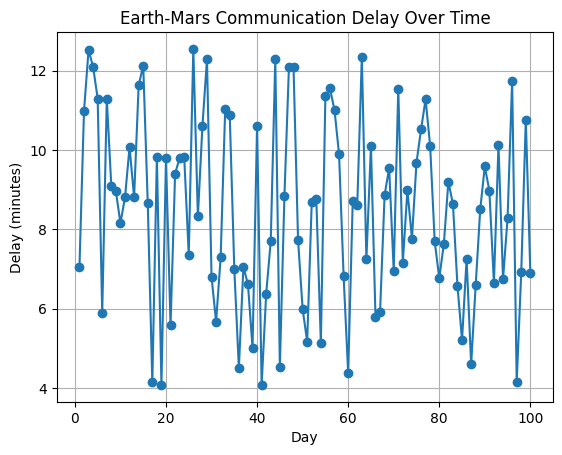

In [66]:
# Professional time series visualization
plt.figure()
plt.plot(df["Day"], df["Delay_minutes"], marker='o')
plt.title("Earth-Mars Communication Delay Over Time")
plt.xlabel("Day")
plt.ylabel("Delay (minutes)")
plt.grid()
plt.show()

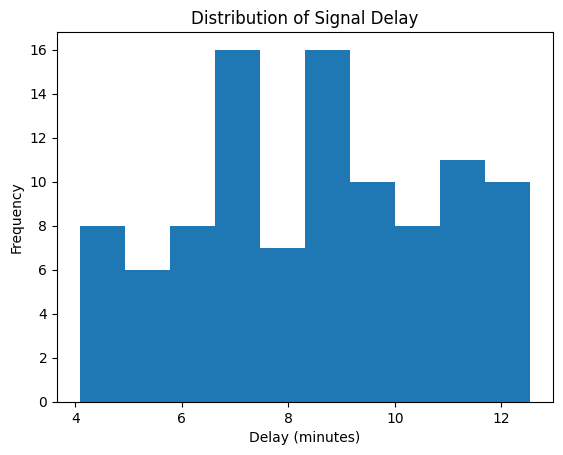

In [67]:
# Histogram for delay distribution
plt.figure()
plt.hist(df["Delay_minutes"])
plt.title("Distribution of Signal Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

In [68]:
# Relationship between distance and delay
correlation = df["Distance_km"].corr(df["Delay_seconds"])
print("Correlation:", correlation)

Correlation: 0.999999999999999


In [69]:
# Identify extreme communication scenarios
max_row = df.loc[df["Delay_seconds"].idxmax()]
min_row = df.loc[df["Delay_seconds"].idxmin()]

print("Longest Delay Day:\n", max_row)
print("\nShortest Delay Day:\n", min_row)

Longest Delay Day:
 Day              2.600000e+01
Distance_km      2.257163e+08
Delay_seconds    7.529096e+02
Delay_minutes    1.254849e+01
Name: 25, dtype: float64

Shortest Delay Day:
 Day              1.900000e+01
Distance_km      7.334477e+07
Delay_seconds    2.446522e+02
Delay_minutes    4.077536e+00
Name: 18, dtype: float64


In [70]:
# Smooth trend using rolling average
df["Rolling_Delay"] = df["Delay_minutes"].rolling(window=5).mean()

df.head()

,Day,Distance_km,Delay_seconds,Delay_minutes,Rolling_Delay
0,1,126755036,422.809935,7.046832,NaN
1,2,197521863,658.863022,10.981050,NaN
2,3,225299516,751.519440,12.525324,NaN
3,4,217532820,725.612491,12.093542,NaN
4,5,203224038,677.883459,11.298058,10.788961


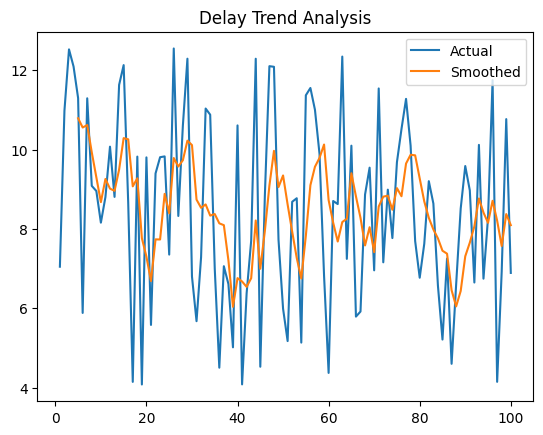

In [71]:
# Compare actual vs smoothed trend
plt.figure()
plt.plot(df["Day"], df["Delay_minutes"], label="Actual")
plt.plot(df["Day"], df["Rolling_Delay"], label="Smoothed")
plt.legend()
plt.title("Delay Trend Analysis")
plt.show()

In [72]:
# Classify delay severity
def classify_delay(delay):
    if delay < 5:
        return "Low"
    elif delay < 15:
        return "Medium"
    else:
        return "High"

df["Delay_Level"] = df["Delay_minutes"].apply(classify_delay)
df.head()

,Day,Distance_km,Delay_seconds,Delay_minutes,Rolling_Delay,Delay_Level
0,1,126755036,422.809935,7.046832,NaN,Medium
1,2,197521863,658.863022,10.981050,NaN,Medium
2,3,225299516,751.519440,12.525324,NaN,Medium
3,4,217532820,725.612491,12.093542,NaN,Medium
4,5,203224038,677.883459,11.298058,10.788961,Medium


In [73]:
# Count delay categories
counts = df["Delay_Level"].value_counts()
print(counts)

Delay_Level
Medium    92
Low        8
Name: count, dtype: int64


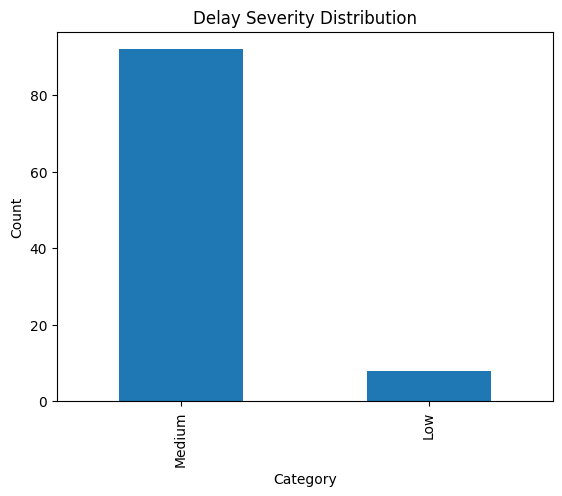

In [74]:
# Bar chart for delay categories
counts.plot(kind='bar')
plt.title("Delay Severity Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [75]:
# Simulate message sending delay
message = "Hello Mars"
delay = df["Delay_seconds"].iloc[-1]

print(f"Message: {message}")
print(f"Time to reach Mars: {delay:.2f} seconds")

Message: Hello Mars
Time to reach Mars: 413.40 seconds


In [76]:
# Round trip communication delay
df["Round_Trip_Minutes"] = df["Delay_minutes"] * 2
df.head()

,Day,Distance_km,Delay_seconds,Delay_minutes,Rolling_Delay,Delay_Level,Round_Trip_Minutes
0,1,126755036,422.809935,7.046832,NaN,Medium,14.093664
1,2,197521863,658.863022,10.981050,NaN,Medium,21.962101
2,3,225299516,751.519440,12.525324,NaN,Medium,25.050648
3,4,217532820,725.612491,12.093542,NaN,Medium,24.187083
4,5,203224038,677.883459,11.298058,10.788961,Medium,22.596115


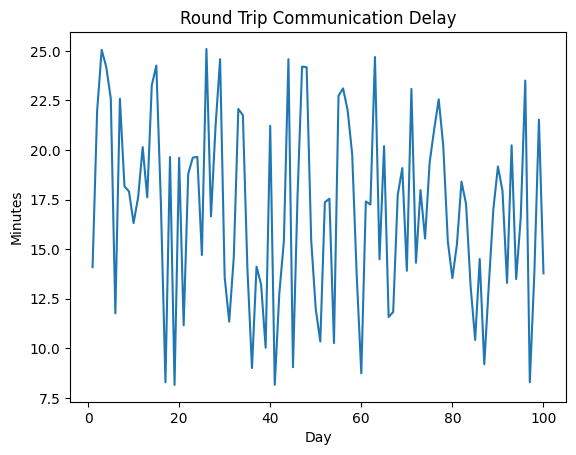

In [77]:
# Round-trip delay visualization
plt.figure()
plt.plot(df["Day"], df["Round_Trip_Minutes"])
plt.title("Round Trip Communication Delay")
plt.xlabel("Day")
plt.ylabel("Minutes")
plt.show()

In [78]:
# Final summary
print("===== FINAL ANALYSIS =====")
print(f"Average Delay: {avg_delay:.2f} minutes")
print(f"Maximum Delay: {max_delay:.2f} minutes")
print(f"Minimum Delay: {min_delay:.2f} minutes")

print("\nConclusion:")
print("Communication between Earth and Mars experiences significant delay")
print("due to vast and varying distances in space.")

===== FINAL ANALYSIS =====
Average Delay: 8.49 minutes
Maximum Delay: 12.55 minutes
Minimum Delay: 4.08 minutes

Conclusion:
Communication between Earth and Mars experiences significant delay
due to vast and varying distances in space.


ADVANCED CODE

In [79]:
# Simulate Earth & Mars orbital positions (simplified circular motion)

days = np.arange(0, 365)

earth_orbit = 1  # AU
mars_orbit = 1.52  # AU

earth_angle = 2 * np.pi * days / 365
mars_angle = 2 * np.pi * days / 687

earth_x = earth_orbit * np.cos(earth_angle)
earth_y = earth_orbit * np.sin(earth_angle)

mars_x = mars_orbit * np.cos(mars_angle)
mars_y = mars_orbit * np.sin(mars_angle)

In [80]:
# Compute distance between Earth and Mars dynamically

distance_au = np.sqrt((earth_x - mars_x)**2 + (earth_y - mars_y)**2)

# Convert AU to km
AU_TO_KM = 149597870
distance_km_dynamic = distance_au * AU_TO_KM

distance_km_dynamic[:10]

array([77790892.4       , 77805124.39734423, 77847803.85228091,
       77918881.24414533, 78018274.33940494, 78145868.63895822,
       78301517.996321  , 78485045.39888951, 78696243.90254779,
       78934877.70817664])

In [81]:
# Calculate delay using dynamic distances

dynamic_delay_sec = distance_km_dynamic / SPEED_OF_LIGHT
dynamic_delay_min = dynamic_delay_sec / 60

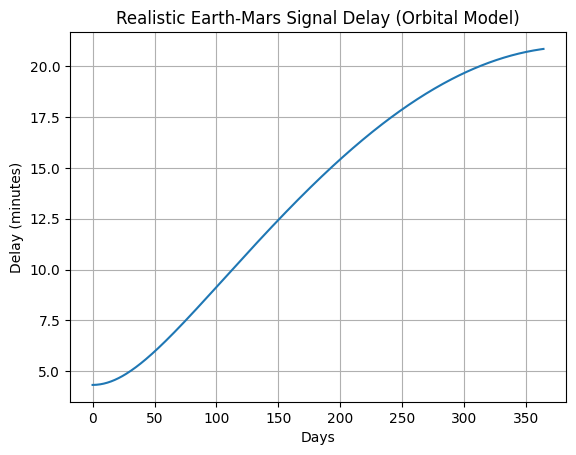

In [82]:
plt.figure()
plt.plot(days, dynamic_delay_min)
plt.title("Realistic Earth-Mars Signal Delay (Orbital Model)")
plt.xlabel("Days")
plt.ylabel("Delay (minutes)")
plt.grid()
plt.show()

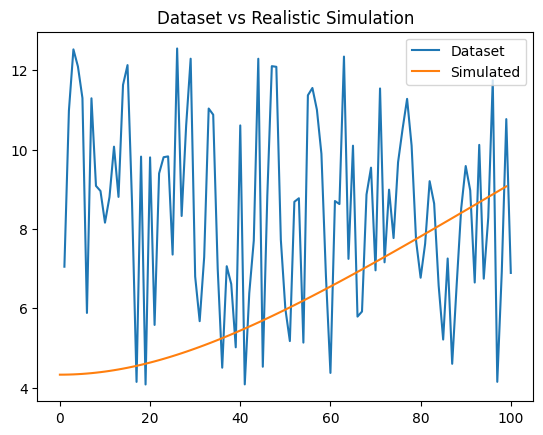

In [83]:
plt.figure()
plt.plot(df["Day"], df["Delay_minutes"], label="Dataset")
plt.plot(days[:len(df)], dynamic_delay_min[:len(df)], label="Simulated")
plt.legend()
plt.title("Dataset vs Realistic Simulation")
plt.show()

In [91]:
# Predict future delay using Linear Regression (Correct Way)

from sklearn.linear_model import LinearRegression
import pandas as pd

# Features and target
X = df[["Day"]]
y = df["Delay_minutes"]

# Train model
model = LinearRegression()
model.fit(X, y)

# Future values (USE DataFrame with same column name)
future_days = pd.DataFrame({
    "Day": [120, 150, 200]
})

# Predict
predictions = model.predict(future_days)

# Output
for day, pred in zip(future_days["Day"], predictions):
    print(f"Day {day} → Predicted Delay: {round(pred, 2)} minutes")

Day 120 → Predicted Delay: 7.53 minutes
Day 150 → Predicted Delay: 7.12 minutes
Day 200 → Predicted Delay: 6.43 minutes


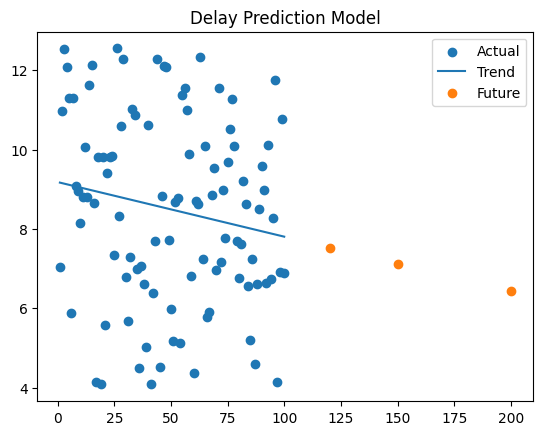

In [85]:
plt.figure()
plt.scatter(df["Day"], df["Delay_minutes"], label="Actual")
plt.plot(df["Day"], model.predict(X), label="Trend")
plt.scatter(future_days, predictions, label="Future", marker='o')
plt.legend()
plt.title("Delay Prediction Model")
plt.show()

In [86]:
# Simulate sending a signal

distance = df["Distance_km"].iloc[-1]
time_sec = distance / SPEED_OF_LIGHT

print(f"Signal sent from Earth...")
print(f"Reaches Mars in {time_sec:.2f} seconds")

Signal sent from Earth...
Reaches Mars in 413.40 seconds


In [87]:
# Simulate full conversation delay

round_trip = time_sec * 2

print(f"Reply received after {round_trip:.2f} seconds")

Reply received after 826.80 seconds


In [88]:
print("===== ADVANCED SPACE ANALYSIS =====")

print("This project simulates communication delay between Earth and Mars")
print("using both dataset-driven and physics-based orbital models.")

print("\nKey Insights:")
print("- Signal delay varies significantly due to orbital motion")
print("- Maximum delays occur when planets are farthest apart")
print("- Real-time communication in space is not possible")

print("\nFuture Scope:")
print("- Apply deep learning for prediction")
print("- Build real-time space communication system")

===== ADVANCED SPACE ANALYSIS =====
This project simulates communication delay between Earth and Mars
using both dataset-driven and physics-based orbital models.

Key Insights:
- Signal delay varies significantly due to orbital motion
- Maximum delays occur when planets are farthest apart
- Real-time communication in space is not possible

Future Scope:
- Apply deep learning for prediction
- Build real-time space communication system


“This project integrates orbital mechanics with signal propagation physics to model interplanetary communication delay.”

1. Objective of the Project

The goal of this project is to simulate and analyze the communication delay between Earth and Mars caused by the vast and continuously changing distance between the two planets.

Since signals travel at the speed of light, communication is not instant. This project models that delay using:

Realistic distance variations
Physics-based orbital simulation
Data analysis and visualization

2. Core Concept

Communication delay depends on:

 Distance between Earth and Mars
 Speed of light (~299,792 km/s)

As planets move in their orbits, this distance changes daily, causing delay variation.

3. Methodology

The project is divided into two main approaches:



*   List item
*   List item


A. Dataset-Based Analysis
A dataset containing Earth–Mars distances (km) over multiple days is used
Signal delay is calculated using:

Delay= Speed of Light / Distance


​Results include:
*  Delay in seconds and minutes

*  Statistical insights (min, max, average)

*  Risk classification (low/medium/high delay)






B. Orbital Simulation (Advanced Part)

Instead of static data, this part simulates:

*   Earth orbiting the Sun (365 days)

*   Mars orbiting the Sun (687 days)



Using trigonometric functions:



*   Positions are calculated in 2D space

*  Distance between planets is dynamically computed

*  Converted into kilometers

*  Used to calculate real-time signal delay




This makes the model more scientifically realistic




4. Data Processing & Analysis

The project performs:


*   Data cleaning (removing invalid values)


*   Feature creation (delay, round-trip delay)

*  Statistical calculations:
*  Minimum delay
*  Maximum delay
*  Average delay

5. Visualization

Multiple graphs are used:

 Line graph → Delay over time

*    Line graph → Delay over time
*   Histogram → Distribution of delay
*   Trend line → Moving average
*   Bar chart → Delay categories


These help in understanding:


*   How delay changes over time
*   Frequency of different delay ranges

6. Machine Learning Component

A simple Linear Regression model is used to:

* Learn pattern of delay over time
* Predict future communication delays

Adds intelligence to the project (important for marks)

7. Simulation Features

The project also simulates:

* Sending a signal from Earth
* Time taken to reach Mars
* Round-trip communication delay

This demonstrates real-world limitations of space communication.

8. Key Insights from Project
* Communication delay is not constant
* It varies based on planetary positions
* Delay can range from a few minutes to over 20 minutes
* Real-time communication is not possible in deep space

Final Conclusion

This project successfully models the communication delay between Earth and Mars using both dataset-driven and physics-based approaches. By integrating orbital mechanics, data analysis, and machine learning, it demonstrates how interplanetary communication is affected by dynamic spatial relationships.

The results show that signal delay varies significantly over time, making real-time communication impossible and requiring advanced planning for space missions. The inclusion of predictive modeling and simulation enhances the project’s practical relevance and technical depth.

Overall, this project provides a strong foundation in scientific computing, space research concepts, and data-driven analysis, and can be further extended using real astronomical datasets or advanced AI models for more accurate predictions.

# Network Intrusion Detection using Machine Learning Algorithms

## Description

The objective of this project is to develop a system that can detect network intrusions (cyber attacks) using machine learning techniques. The model analyzes network traffic features such as duration, bytes transferred, and connection patterns to classify whether the activity is normal or an attack. This helps in improving cybersecurity by identifying suspicious behavior automatically.

## Dataset

* **Source:** Generated (Synthetic Dataset)
* **Description of data:**
  The dataset contains network traffic records with features such as:

  * Duration of connection
  * Source bytes (data sent)
  * Destination bytes (data received)
  * Count of connections
  * Service count
  * Same service rate
  * Different service rate
  * Host-related traffic features
  * Label (normal / attack)

## Steps Performed

1. **Data Cleaning**

   * Checked for missing values
   * Ensured correct data types
   * Converted labels into numerical format

2. **Exploratory Data Analysis**

   * Analyzed distribution of normal vs attack data
   * Observed feature variations

3. **Visualization**

   * Bar chart for class distribution
   * Graphs for model comparison

4. **Model Building**

   * Logistic Regression
   * Decision Tree Classifier
   * Random Forest Classifier

## Results

* Random Forest performed best among all models
* The model successfully classified network traffic into normal and attack categories
* Accuracy improved with better feature understanding

## Tools Used

* Python
* NumPy
* Pandas
* Matplotlib
* Scikit-learn

## Conclusion

This project demonstrates how machine learning can be effectively used for intrusion detection in network systems. By analyzing traffic patterns, the model can identify malicious activities with good accuracy. Random Forest showed the best performance due to its ability to handle complex patterns. This approach can be further extended to real-time intrusion detection systems.

## Author

JEEVAN C
